In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [2]:
df = pd.read_csv('Hotel_Reviews[1].csv')

In [4]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [6]:
df['Negative_Review'] = df['Negative_Review'].fillna('')
df['Positive_Review'] = df['Positive_Review'].fillna('')

#COMBINING BOTH INTO SINGLE COLUMN
df['Combined_Review'] = df['Negative_Review'] + " " + df['Positive_Review']

df['Combined_Review'] = df['Combined_Review'].str.replace('No Negative', '', case=False)
df['Combined_Review'] = df['Combined_Review'].str.replace('No Positive', '', case=False)

In [7]:
# TEXT CLEANING

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(f'[{string.punctuation}]', '', text)
    text = re.sub(r'\d+', '', text)

    # Tokenization & Lemmatization, skipping stopwords
    tokens = text.split()
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(cleaned_tokens)

In [9]:
# Apply cleaning
df['Cleaned_Review'] = df['Combined_Review'].apply(clean_text)

# Drop rows where the review became completely empty after cleaning
df = df[df['Cleaned_Review'].str.strip() != ''].reset_index(drop=True)

print(f"Preprocessing Complete! New DataFrame Shape: {df.shape}")
display(df[['Hotel_Name', 'Reviewer_Score', 'Combined_Review', 'Cleaned_Review']].head(2))

Preprocessing Complete! New DataFrame Shape: (515122, 19)


,Hotel_Name,Reviewer_Score,Combined_Review,Cleaned_Review
0,Hotel Arena,2.9,I am so angry that i made this post available...,angry made post available via possible site us...
1,Hotel Arena,7.5,No real complaints the hotel was great great...,real complaint hotel great great location surr...


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Create ground-truth sentiment labels based on the Reviewer_Score
def assign_rating_label(score):
    if score >= 8.0:
        return 'Positive'
    elif score <= 6.0:
        return 'Negative'
    else:
        return 'Neutral'

df['Rating_Label'] = df['Reviewer_Score'].apply(assign_rating_label)

# Filter out Neutral if we want a clean binary or 3-class model (let's keep 3-class for completeness)
print("Distribution of Ratings-based Sentiment:")
print(df['Rating_Label'].value_counts())

# Step 2: Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['Cleaned_Review'])
y = df['Rating_Label']

# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a Logistic Regression Classifier
print("\nTraining Sentiment Classification Model...")
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)

# Step 5: Evaluate Model
y_pred = classifier.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save predictions back to dataframe for the final report
df['Predicted_Sentiment'] = classifier.predict(X)

Distribution of Ratings-based Sentiment:
Rating_Label
Positive    335240
Neutral     127194
Negative     52688
Name: count, dtype: int64

Training Sentiment Classification Model...
Model Accuracy: 73.78%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.47      0.54     10368
     Neutral       0.52      0.39      0.45     25296
    Positive       0.80      0.91      0.85     67361

    accuracy                           0.74    103025
   macro avg       0.66      0.59      0.61    103025
weighted avg       0.72      0.74      0.72    103025




Top Service Issues Mentioned by Customers:


,count
Service_Issues,
Room Quality,277836
Staff Behavior,262349
Food Service,183223
Cleanliness,142046
Amenities,85885
General / Other,67440


/tmp/ipykernel_5461/4023988507.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=issue_counts.values, y=issue_counts.index, palette='Reds_r')


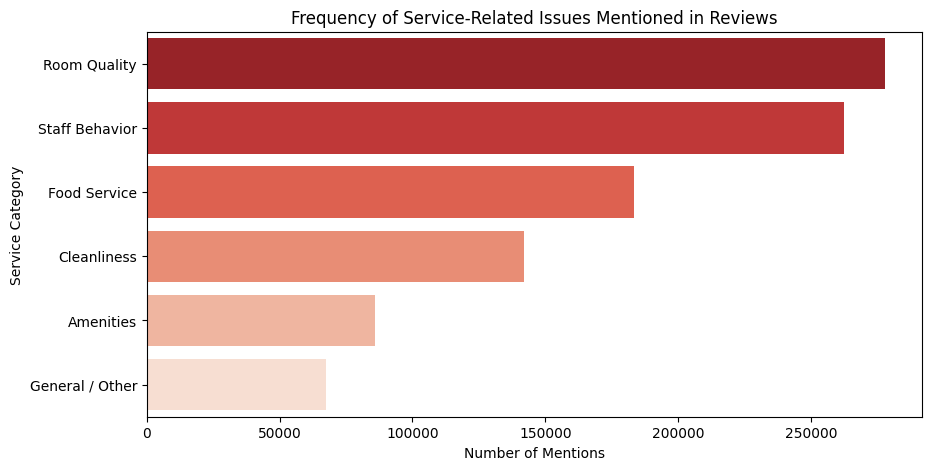

In [12]:
# Define category keywords to scan within negative or low-scoring reviews
service_categories = {
    'Cleanliness': ['clean', 'dirty', 'dusty', 'stain', 'smell', 'mold', 'hair', 'bathroom', 'room service', 'towels'],
    'Staff Behavior': ['staff', 'reception', 'rude', 'helpful', 'manager', 'service', 'unfriendly', 'checkin', 'front desk'],
    'Food Service': ['breakfast', 'food', 'restaurant', 'dinner', 'coffee', 'buffet', 'meal', 'taste', 'cold'],
    'Room Quality': ['bed', 'noise', 'ac', 'air conditioning', 'view', 'small', 'noisy', 'window', 'mattress', 'pillow'],
    'Amenities': ['wifi', 'internet', 'pool', 'gym', 'elevator', 'parking', 'facility', 'spa']
}

def identify_issues(text):
    text = str(text).lower()
    issues_found = []
    for category, keywords in service_categories.items():
        if any(keyword in text for keyword in keywords):
            issues_found.append(category)
    return issues_found if issues_found else ['General / Other']

# Apply issue extraction to reviews with negative sentiments or low scores
df['Service_Issues'] = df['Combined_Review'].apply(identify_issues)

# Explode the list of issues to calculate frequency counts
issues_exploded = df.explode('Service_Issues')
issue_counts = issues_exploded['Service_Issues'].value_counts()

print("\nTop Service Issues Mentioned by Customers:")
display(issue_counts)

# Visualize the issues
plt.figure(figsize=(10, 5))
sns.barplot(x=issue_counts.values, y=issue_counts.index, palette='Reds_r')
plt.title('Frequency of Service-Related Issues Mentioned in Reviews')
plt.xlabel('Number of Mentions')
plt.ylabel('Service Category')
plt.show()

       CUSTOMER SATISFACTION REPORT       
Total Reviews Analyzed: 515,122
Average Hotel Rating: 8.39 / 10
Positive Reviews: 65.1%
Neutral Reviews:  24.7%
Negative Reviews: 10.2%

Service Category Performance:


,Category,Total Mentions,Average Score
0,Cleanliness,142046,8.13
1,Staff Behavior,262349,8.53
2,Food Service,183223,8.41
3,Room Quality,277836,8.22
4,Amenities,85885,8.29


/tmp/ipykernel_5461/300484386.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Average Score', y='Category', palette='viridis')


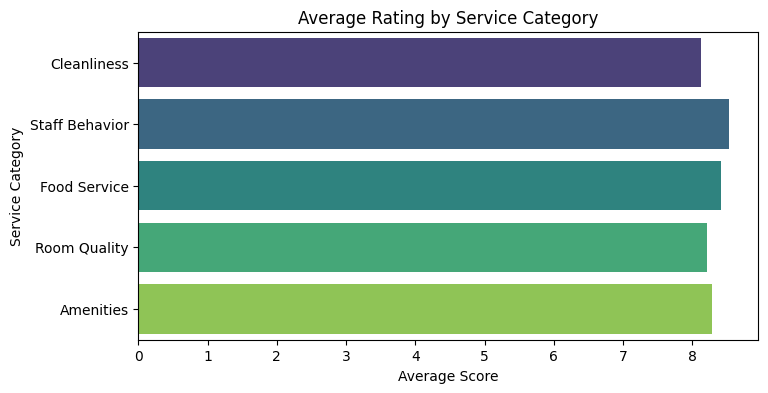


--- Management Recommendations ---
1. Focus on categories with the lowest average scores.
2. Improve staff training and room cleanliness standards.
3. Regularly monitor guest reviews to catch issues early.


In [13]:
# Step 1: Print simple summary results

print("       CUSTOMER SATISFACTION REPORT       ")
print(f"Total Reviews Analyzed: {len(df):,}")
print(f"Average Hotel Rating: {df['Reviewer_Score'].mean():.2f} / 10")

# Calculate sentiment percentages
sentiments = df['Rating_Label'].value_counts(normalize=True) * 100
print(f"Positive Reviews: {sentiments.get('Positive', 0):.1f}%")
print(f"Neutral Reviews:  {sentiments.get('Neutral', 0):.1f}%")
print(f"Negative Reviews: {sentiments.get('Negative', 0):.1f}%")
print("==========================================")

# Step 2: Simple category summary table
summary_data = []
for category in service_categories.keys():
    subset = df[df['Service_Issues'].apply(lambda x: category in x)]
    summary_data.append({
        'Category': category,
        'Total Mentions': len(subset),
        'Average Score': round(subset['Reviewer_Score'].mean(), 2)
    })

summary_df = pd.DataFrame(summary_data)
print("\nService Category Performance:")
display(summary_df)

# Step 3: Simple bar chart for category scores
plt.figure(figsize=(8, 4))
sns.barplot(data=summary_df, x='Average Score', y='Category', palette='viridis')
plt.title('Average Rating by Service Category')
plt.xlabel('Average Score')
plt.ylabel('Service Category')
plt.show()

# Step 4: Basic Recommendations
print("\n--- Management Recommendations ---")
print("1. Focus on categories with the lowest average scores.")
print("2. Improve staff training and room cleanliness standards.")
print("3. Regularly monitor guest reviews to catch issues early.")